In [1]:
import matplotlib.image as img
import matplotlib.pyplot as plt
import copy
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from os import listdir
from sklearn.model_selection import train_test_split
import seaborn as sns;sns.set()
from sklearn import metrics

The objective is to work with a flower dataset...Each flower is noted with some measurements of the leaves as well as the name of the flower...

In [4]:
iris = pd.read_csv("/Users/mohammedsadmanuddin/data analysis/Machine Learning 1/iris_data.csv")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


Each column might be an interesting var to try and predict when a new flower comes in...the obv first choice here is the species column..cuz  it shows exactly what kind of flower we have...trying to predict this based on the measurements of the leaves is a typical example of CLASSIFICATION...the remaining columns can also be interesting to predict...based on the width of the leaf and the type of the flower...then its possible to predict exactly how long the leaf was...this is a typical example of REGRESSION

In [5]:
iris.shape

(150, 5)

In [6]:
iris.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

ALL the columns are floats except the species column...this is to be expected as column contain the name of flowers(known as "Label" in ML)

In [7]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


there is no missing values as the count is 150 accross all columns

In [9]:
ML_Model = RandomForestClassifier()
ML_Model

RandomForestClassifier()

-X is the raw dataset which it can use to learn the appropriate patterns
-Y the outcome vector(The labels it should try to learn)
it is extreamly important to make sure that the outcome vector Y is not X
if we include Y in our X,The model will use Y to predict Y.
Of Course this means it will not learn anything from the data and just repeat what is in the Y column.

In [10]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [11]:
X = iris[['sepal_length','sepal_width','petal_length','petal_width']]
Y = iris['species']

In [12]:
ML_Model.fit(X,Y)
ML_Model

RandomForestClassifier()

In [13]:
##testing
fakeflower = pd.DataFrame({'sepal_length':5,'sepal_width':3,'petal_length':1,'petal_width':0.5},index =[0])
fakeflower

,sepal_length,sepal_width,petal_length,petal_width
0,5,3,1,0.5


In [14]:
ML_Model.predict(fakeflower)

array(['setosa'], dtype=object)

In [16]:
y_pred = ML_Model.predict(X)

Text(0.5, 152.24999999999994, 'Predicted flower')

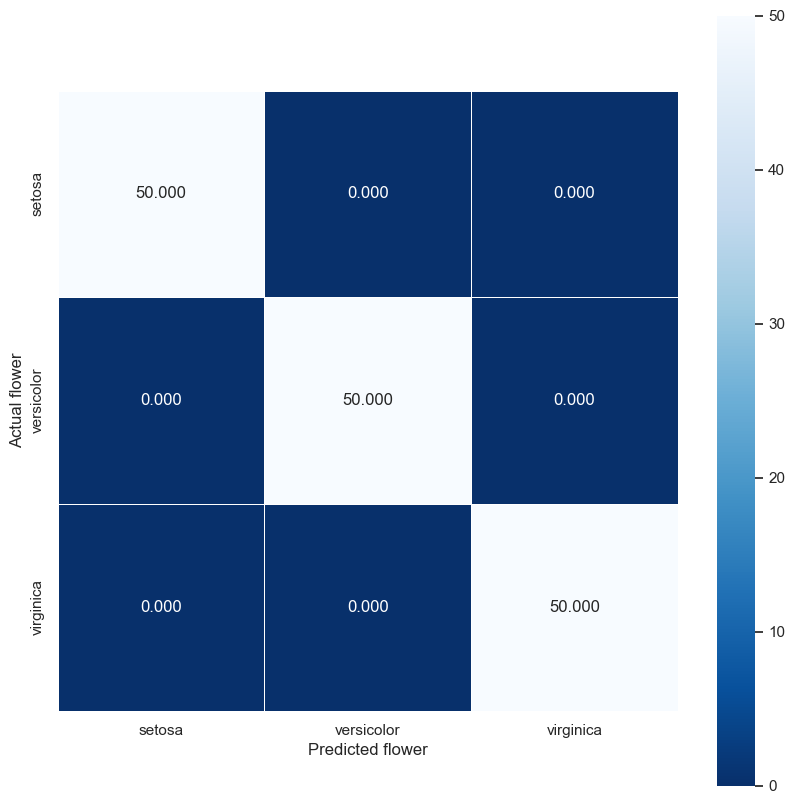

In [17]:
labels = ['setosa','versicolor','virginica']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(Y,y_pred,labels=labels),annot=True,fmt='.3f',linewidths=.5,square=True,cmap='Blues_r',xticklabels=labels,yticklabels=labels)
plt.ylabel('Actual flower')
plt.xlabel('Predicted flower')

the heatmap shows a correct diagonal accurate pre...where teh actual setosa and the predict setosa is same ...same goes for others but the actual setosa and predict versicolor is not same...The true class was setosa, but the model predicted versicolor

Also we are testing the model om the same data we used to train it...its like taking a test with the exact same question from the practice test
we can fix this using train-test split..with that we can divide our data into two parts...one for training the model(the training set) and one for testing it afterwards

In [18]:
X_train, X_test, Y_train,Y_test = train_test_split(X,Y,test_size=0.25)

In [ ]:
X_train.shape #75% of original

(112, 4)

In [ ]:
X_test.shape #25% of original

(38, 4)

###train and test
this function split a dataset into 2...one for training and one for testing
X_train,Y_train == this is the data the models learns from
X_test,Y_test== this is the held back which is never shown in training


X_train = inputdata for learning
X_test = new inputs unseen
Y_train = Correct ans for learning
Y_test = true answer for evaluation

so it gives us number of things
1=training data(X_train)
2=training outcome to predict(y_train)
3=test data(X_test)
4=test outcome to predict

In [22]:
ML_model = RandomForestClassifier()
ML_model
ML_model.fit(X_train,Y_train)

RandomForestClassifier()

Text(0.5, 152.24999999999994, 'predicted flower')

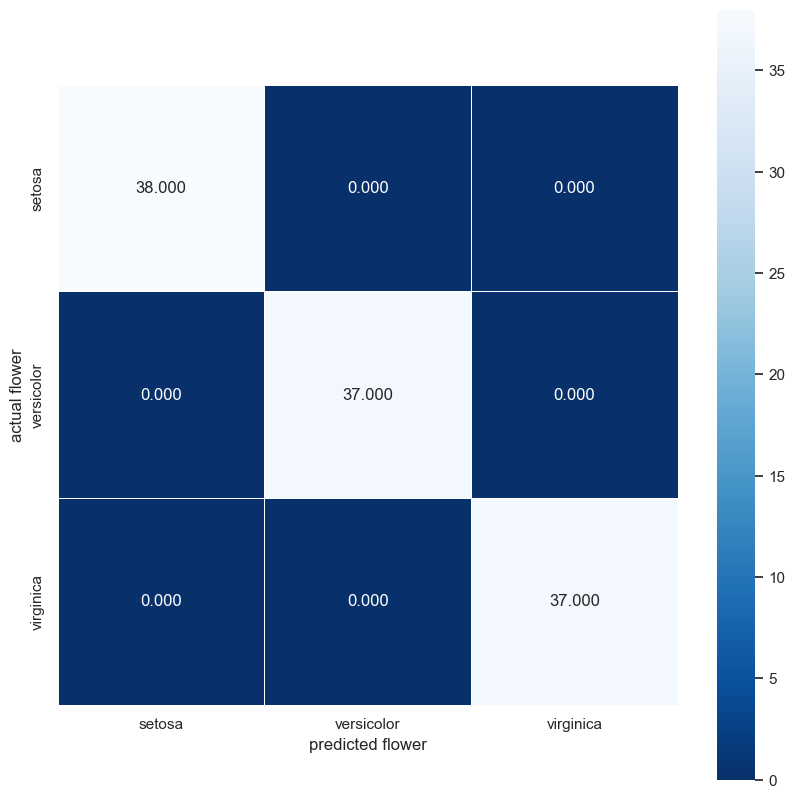

In [24]:
y_pred = ML_model.predict(X_train)
labels = ['setosa','versicolor','virginica']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(Y_train,y_pred,labels=labels),annot=True,fmt='.3f',linewidths=.5,square=True,cmap='Blues_r',xticklabels=labels,yticklabels=labels)
plt.ylabel('actual flower')
plt.xlabel('predicted flower')

Text(0.5, 152.24999999999994, 'predicted flower')

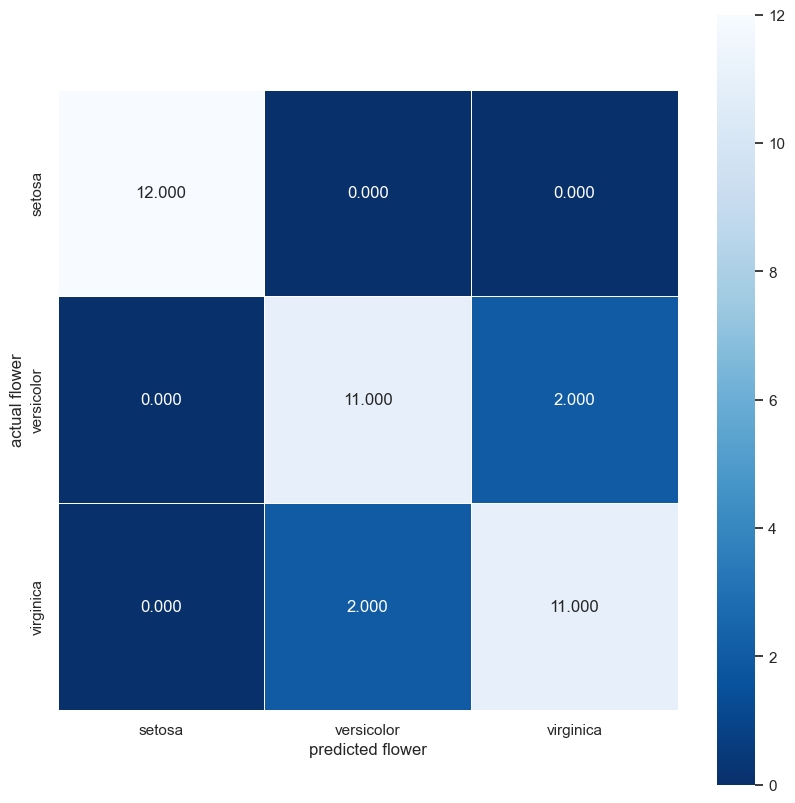

In [25]:
#now with the unseen test data
y_pred = ML_model.predict(X_test)
labels = ['setosa','versicolor','virginica']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(Y_test,y_pred,labels=labels),annot=True,fmt='.3f',linewidths=.5,square=True,cmap='Blues_r',xticklabels=labels,yticklabels=labels)
plt.ylabel('actual flower')
plt.xlabel('predicted flower')

From this one ...the result on unseen data are not perfect...2 versicolor are predicted as virginica...but the result is still good...that means the model has learned the problem.